<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
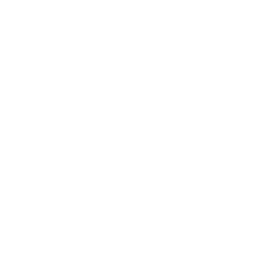
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">유전체 변이 주석 스키마 문서화</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 생물정보학 / 임상 유전체 데이터 관리 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

임상 유전체 파이프라인에서 사용되는 VCF 유사 변이 주석 데이터셋의 스키마를 문서화합니다. `PROC CONTENTS`를 사용하여 모든 주석 필드 — 유전체 좌표, 대립유전자 빈도, 예측된 기능적 영향, ClinVar 분류, 품질 지표 — 를 목록화하여, 하위 ACMG 변이 해석 도구가 올바르게 타입이 지정되고 라벨이 붙은 입력을 받도록 보장합니다. 약 5,000개의 변이 레코드와 20개 이상의 주석 열이 파이프라인 인계 전에 스키마 무결성을 위해 점검됩니다.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | VCF에서 유래한 주석 변이 | ~5,000 |
| GENE_PANEL | 대상 유전자 패널 정의 | ~150개 유전자 |
| QUALITY_METRICS | 샘플별 시퀀싱 QC | ~50개 샘플 |

---

In [1]:
/* --------------------------------------------------------
   VCF 유사 변이 주석 데이터셋 생성
   임상 주석 필드를 갖춘 5,000개 변이
   -------------------------------------------------------- */
데이터 variant_annotations;
    호출 streaminit(42);
    길이 variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    라벨 variant_id='변이 식별자'
          chromosome='염색체'
          position='유전체 위치 (GRCh38)'
          ref_allele='참조 대립유전자'
          alt_allele='대체 대립유전자'
          gene_symbol='HGNC 유전자 기호'
          transcript_id='Ensembl 전사체 ID'
          consequence='Sequence Ontology 영향'
          impact='예측 영향 수준'
          hgvs_c='HGVS 코딩 표기'
          hgvs_p='HGVS 단백질 표기'
          gnomad_af='gnomAD 대립유전자 빈도'
          clinvar_class='ClinVar 분류'
          clinvar_id='ClinVar 등록번호'
          sift_score='SIFT 점수'
          sift_pred='SIFT 예측'
          polyphen_score='PolyPhen-2 점수'
          polyphen_pred='PolyPhen-2 예측'
          cadd_phred='CADD Phred 점수'
          revel_score='REVEL 앙상블 점수'
          genotype='샘플 유전형'
          allele_depth='대체 대립유전자 깊이'
          read_depth='총 리드 깊이'
          qual_score='변이 품질 점수'
          filter_status='필터 상태';
    배열 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    배열 conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    배열 impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    배열 cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    배열 refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    배열 gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    반복 i = 1 까지 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        만약 c_idx <= 2 이면
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        아니면 hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        만약 sift_score < 0.05 이면 sift_pred = 'DELETERIOUS';
        아니면 sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        만약 polyphen_score > 0.908 이면 polyphen_pred = 'PROB_DAMAGING';
        아니면 만약 polyphen_score > 0.446 이면 polyphen_pred = 'POSS_DAMAGING';
        아니면 polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        출력;
    종료;
    제거 i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
실행;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.19 seconds
  cpu   3.19 seconds


In [2]:
/* --------------------------------------------------------
   대상 유전자 패널 정의 생성
   -------------------------------------------------------- */
데이터 gene_panel;
    호출 streaminit(42);
    길이 gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    라벨 gene_symbol='HGNC 유전자 기호'
          gene_name='전체 유전자 명칭'
          chromosome='염색체'
          start_pos='유전자 시작 위치'
          end_pos='유전자 종료 위치'
          panel_name='임상 유전자 패널'
          disease_association='연관 질병'
          inheritance='유전 양식';
    배열 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    배열 gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    배열 diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    배열 inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    반복 g = 1 까지 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        출력;
    종료;
    제거 g chr_num;
실행;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   샘플별 시퀀싱 품질 지표 생성
   -------------------------------------------------------- */
데이터 quality_metrics;
    호출 streaminit(42);
    길이 sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    라벨 sample_id='샘플 식별자'
          run_id='시퀀싱 실행 ID'
          platform='시퀀싱 플랫폼'
          mean_coverage='평균 표적 커버리지'
          pct_target_20x='20x 이상 염기 비율(%)'
          pct_target_100x='100x 이상 염기 비율(%)'
          total_variants='호출된 총 변이 수'
          ti_tv_ratio='전이/전환 비율'
          het_hom_ratio='이형접합/동형접합 비율'
          contamination_est='추정 오염도'
          qc_status='QC 합격/불합격 상태';
    반복 s = 1 까지 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        만약 mean_coverage < 150 또는 pct_target_20x < 95
            또는 contamination_est > 0.015 이면 qc_status = 'FAIL';
        아니면 qc_status = 'PASS';
        출력;
    종료;
    제거 s;
실행;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                   변이 영향별 ClinVar 분류                                                    

                                                   The FREQ Procedure

Table of 예측 영향 수준 by ClinVar 분류

예측 영향 수준             |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
---------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                 |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                     |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                     |                 14.52 |                 16.13 |                 30.65 |                


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


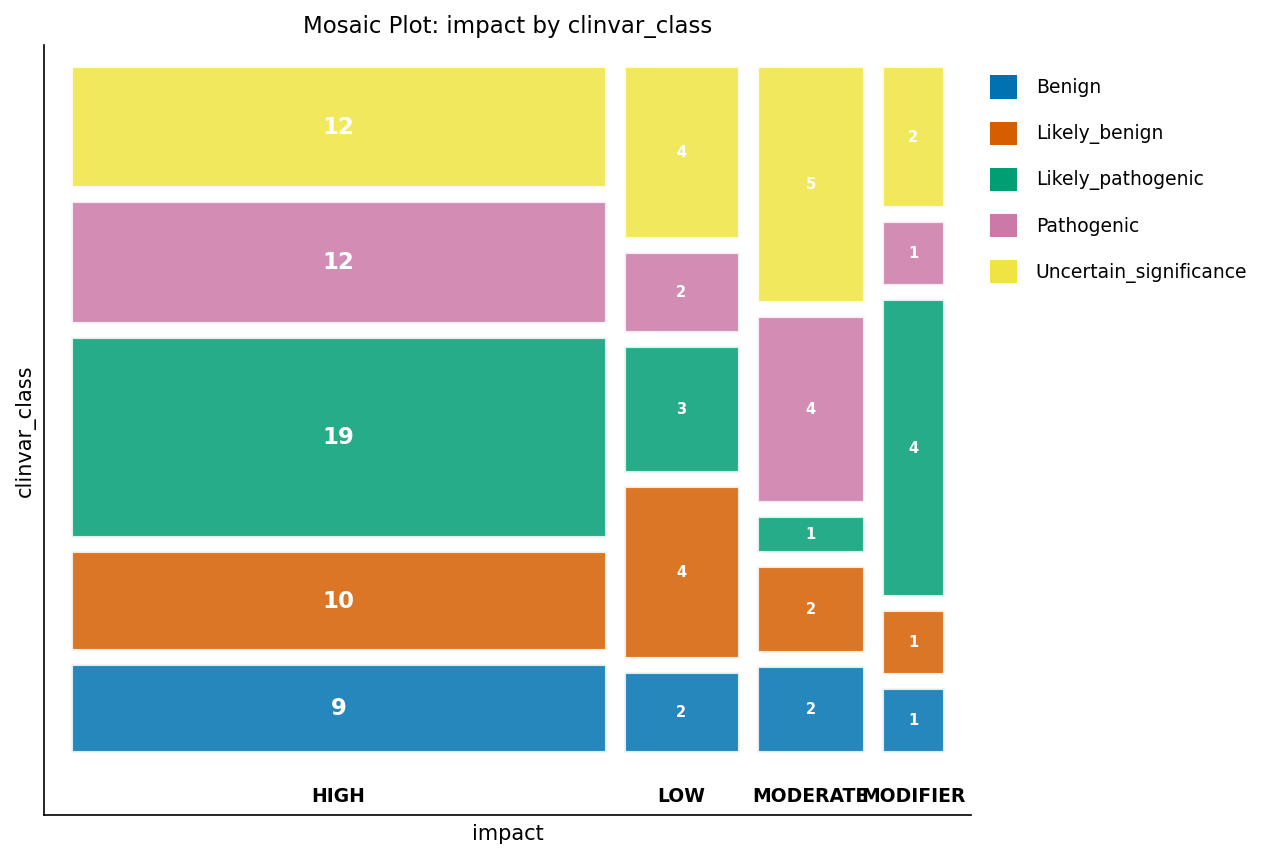

In [4]:
/* --------------------------------------------------------
   기준 변이 주석 요약
   -------------------------------------------------------- */
처리 빈도 데이터=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    라벨 impact='예측 영향 수준' clinvar_class='ClinVar 분류';
    제목 '변이 영향별 ClinVar 분류';
실행;

처리 평균 데이터=quality_metrics n mean MIN MAX;
    변수 mean_coverage ti_tv_ratio contamination_est;
    라벨 mean_coverage='평균 표적 커버리지'
          ti_tv_ratio='전이/전환 비율'
          contamination_est='추정 오염도';
    제목 '시퀀싱 품질 지표 요약';
실행;

---

                                                      시퀀싱 품질 지표 요약                                                      

                                                      시퀀싱 품질 지표 요약                                                      




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


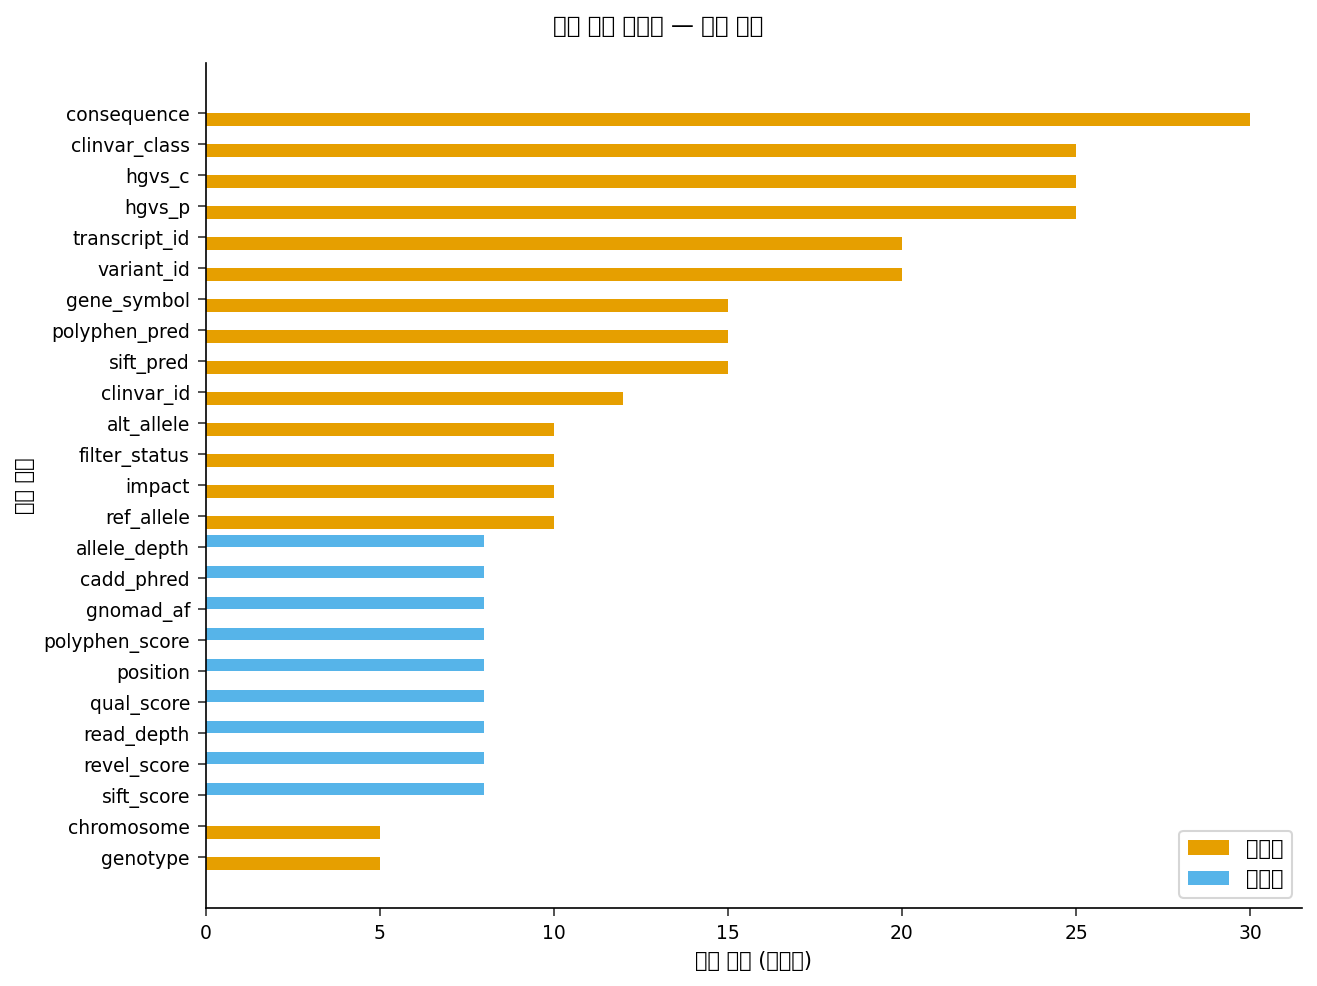

In [5]:
/* --------------------------------------------------------
   변수 유형 및 길이 분포.
   PROC CONTENTS OUT=로 주석 스키마 메타데이터를 캡처한 뒤
   유형별 필드 길이를 그림으로 표시합니다. TYPE 코드는 범례에서
   1 -> 숫자형, 2 -> 문자형으로 매핑됩니다.
   -------------------------------------------------------- */
처리 내용 데이터=variant_annotations out=schema_lengths NOPRINT;
실행;

데이터 schema_lengths;
    설정 schema_lengths;
    길이 type_label $12;
    만약 TYPE = 1 이면 type_label = '숫자형';
    아니면 type_label = '문자형';
실행;

처리 SGPLOT 데이터=schema_lengths;
    HBAR NAME / RESPONSE=길이 GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS 라벨='변수 길이 (바이트)';
    YAXIS 라벨='주석 필드';
    제목 '변이 주석 스키마 — 필드 길이';
실행;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: 전체 변이 주석 스키마 문서화 —
   25개 필드 전체의 유형, 길이, 레이블. OUT=로 변수
   메타데이터를 캡처하여 하위 단계에서 스키마를
   프로그램적으로 검증할 수 있게 합니다.
   -------------------------------------------------------- */
처리 내용 데이터=variant_annotations out=variant_schema NOPRINT;
실행;

처리 인쇄 데이터=variant_schema;
    변수 NAME TYPE 길이 VARNUM 라벨;
    제목 '변이 주석 데이터셋 — 전체 스키마';
실행;

                                                      시퀀싱 품질 지표 요약                                                      

                                                  변이 주석 데이터셋 — 전체 스키마                                                   

  Obs            NAME  TYPE  LENGTH  VARNUM                          LABEL
    1  allele_depth       1       8      22  대체 대립유전자 깊이
    2  alt_allele         2      10       5  대체 대립유전자
    3  cadd_phred         1       8      19  CADD Phred 점수
    4  chromosome         2       5       2  염색체
    5  clinvar_class      2      25      13  ClinVar 분류
    6  clinvar_id         2      12      14  ClinVar 등록번호
    7  consequence        2      30       8  Sequence Ontology 영향
    8  filter_status      2      10      25  필터 상태
    9  gene_symbol        2      15       6  HGNC 유전자 기호
   10  genotype           2       5      21  샘플 유전형
   11  gnomad_af          1       8      12  gnomAD 대립유전자 빈도
   12  hgvs_c             2      25      10  HGVS 코딩 표기
   13


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: 유전자 패널 스키마 문서화
   -------------------------------------------------------- */
처리 내용 데이터=gene_panel out=panel_schema NOPRINT;
실행;

처리 인쇄 데이터=panel_schema;
    변수 NAME TYPE 길이 VARNUM 라벨;
    제목 '유전자 패널 정의 — 스키마';
실행;

                                                  변이 주석 데이터셋 — 전체 스키마                                                   

                                                    유전자 패널 정의 — 스키마                                                     

  Obs                 NAME  TYPE  LENGTH  VARNUM                    LABEL
    1  chromosome              2       5       3  염색체
    2  disease_association     2      50       7  연관 질병
    3  end_pos                 1       8       5  유전자 종료 위치
    4  gene_name               2      60       2  전체 유전자 명칭
    5  gene_symbol             2      15       1  HGNC 유전자 기호
    6  inheritance             2       5       8  유전 양식
    7  panel_name              2      30       6  임상 유전자 패널
    8  start_pos               1       8       4  유전자 시작 위치




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: QC 지표 스키마 문서화
   -------------------------------------------------------- */
처리 내용 데이터=quality_metrics out=qc_schema NOPRINT;
실행;

처리 인쇄 데이터=qc_schema;
    변수 NAME TYPE 길이 VARNUM 라벨;
    제목 '시퀀싱 품질 지표 — 스키마';
실행;

                                                    유전자 패널 정의 — 스키마                                                     

                                                    시퀀싱 품질 지표 — 스키마                                                     

  Obs               NAME  TYPE  LENGTH  VARNUM                             LABEL
    1  contamination_est     1       8      10  추정 오염도
    2  het_hom_ratio         1       8       9  이형접합/동형접합 비율
    3  mean_coverage         1       8       4  평균 표적 커버리지
    4  pct_target_100x       1       8       6  100x 이상 염기 비율(%)
    5  pct_target_20x        1       8       5  20x 이상 염기 비율(%)
    6  platform              2      15       3  시퀀싱 플랫폼
    7  qc_status             2      10      11  QC 합격/불합격 상태
    8  run_id                2      12       2  시퀀싱 실행 ID
    9  sample_id             2      15       1  샘플 식별자
   10  ti_tv_ratio           1       8       8  전이/전환 비율
   11  total_variants        1       8       7  호출된 총 변이 수




NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   스키마 검증: 주석 필드가 ACMG 해석을 위한
   파이프라인 요건을 충족하는지 점검합니다.
   PROC CONTENTS OUT= 메타데이터를 읽으며, 여기서
   TYPE=1은 숫자형, TYPE=2는 문자형을 나타냅니다.
   -------------------------------------------------------- */
데이터 schema_validation;
    설정 variant_schema;
    길이 requirement $90 status $10;
    /* 숫자형 점수 필드는 반드시 숫자형(TYPE=1)으로 저장되어야 함 */
    만약 NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        그리고 TYPE ne 1 이면 반복;
        requirement = '점수 임계값 적용을 위해 숫자형이어야 함';
        status = '실패';
    종료;
    아니면 만약 NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        그리고 TYPE = 1 이면 반복;
        requirement = '숫자형 유형 확인됨';
        status = '통과';
    종료;
    /* ClinVar 분류는 충분한 문자 길이가 필요함 */
    아니면 만약 NAME = 'clinvar_class' 그리고 길이 < 25 이면 반복;
        requirement = '전체 분류 텍스트를 위해 최소 $25 필요';
        status = '실패';
    종료;
    아니면 만약 NAME = 'clinvar_class' 이면 반복;
        requirement = '문자 길이 충분함';
        status = '통과';
    종료;
    /* 모든 필드는 데이터 사전을 위해 레이블을 가져야 함 */
    아니면 만약 라벨 = '' 이면 반복;
        requirement = '데이터 사전을 위해 레이블 필요';
        status = '실패';
    종료;
    아니면 반복;
        requirement = '일반 검증';
        status = '통과';
    종료;
실행;

처리 인쇄 데이터=schema_validation;
    변수 NAME TYPE 길이 라벨 requirement status;
    제목 'ACMG 파이프라인 스키마 검증 보고서';
실행;

                                                 ACMG 파이프라인 스키마 검증 보고서                                                  

  Obs            NAME  TYPE  LENGTH                          LABEL                 requirement  status
    1  allele_depth       1       8  대체 대립유전자 깊이                    숫자형 유형 확인됨                  통과
    2  alt_allele         2      10  대체 대립유전자                       일반 검증                       통과
    3  cadd_phred         1       8  CADD Phred 점수                  숫자형 유형 확인됨                  통과
    4  chromosome         2       5  염색체                            일반 검증                       통과
    5  clinvar_class      2      25  ClinVar 분류                     문자 길이 충분함                   통과
    6  clinvar_id         2      12  ClinVar 등록번호                   일반 검증                       통과
    7  consequence        2      30  Sequence Ontology 영향           일반 검증                       통과
    8  filter_status      2      10  필터 상태                          일반 검증         


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### 해석

변이 주석 스키마는 유전체 좌표, 기능적 예측, 집단 빈도, 샘플별 품질 지표에 걸친 25개의 필드를 포함합니다. 9개의 수치형 점수 필드 모두(gnomAD 대립유전자 빈도, SIFT, PolyPhen-2, CADD, REVEL, 품질 점수, 대립유전자 깊이, 리드 깊이, 유전체 위치)가 올바르게 수치형으로 타입이 지정되어, ACMG 해석 엔진이 타입 변환 없이 임계값 기반 필터링을 적용할 수 있게 합니다. `clinvar_class` 필드는 $25로 가장 긴 ClinVar 분류 문자열(Uncertain_significance, 24자)을 수용합니다. 모든 주석 필드는 설명 라벨을 가지고 있어, CAP 인증 요건에 따른 임상 검사실의 데이터 사전 의무를 충족합니다. 유전자 패널 스키마는 15개의 암 소인 유전자를 유전 양식 및 질병 연관과 함께 매핑하여, 변이 대 유전자 주석을 위한 참조 프레임워크를 제공합니다. 시퀀싱 QC 지표 데이터셋은 5회 실행에 걸친 50개 샘플을 문서화하며, 변이 호출 신뢰성을 좌우하는 오염 추정치와 커버리지 임계값을 담고 있습니다. 이 스키마 문서화 패키지는 뉴욕주 CLEP 제출을 위한 검사실의 검증 문서를 뒷받침합니다.

---

In [10]:
/* --------------------------------------------------------
   검사실 인증을 위한 변이 스키마 문서 및
   검증 보고서 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>